# importlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import os

# importing data

In [2]:
BASE_PATH = "../Data/"

DATA_PATH = os.path.join(BASE_PATH, "swat_preprocessed")


In [3]:
X_train = np.load(os.path.join(DATA_PATH, "X_train.npy"))
X_test = np.load(os.path.join(DATA_PATH, "X_test.npy"))
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))
x_val = np.load(os.path.join(DATA_PATH, "x_val.npy"))

# flatten data

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = x_val.reshape(x_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flat features shape: {X_test_flat.shape}")

Flat features shape: (120184, 564)


# free space

In [5]:
import gc

# Delete the non-windowed or raw dataframes once you have the windowed tensors
del X_train, x_val, X_test

# Force Python to release the memory back to the OS
gc.collect()

33

## Preparing for the USAD

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

In [7]:
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_flat, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)

In [8]:
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor), batch_size=512, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=512, shuffle=False)

## implementing the model

In [9]:
WINDOW_SIZE=12

In [10]:
num_features = X_test_flat.shape[1] // WINDOW_SIZE # Since we have 12 time steps in the window
input_dim = num_features * WINDOW_SIZE # This will be 51 * 12 = 612
hidden_dim = 128 # Increased slightly to handle larger input


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(True),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(True),
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.ReLU(True)
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim // 4, hidden_dim // 2), nn.ReLU(True),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(True),
            nn.Linear(hidden_dim, input_dim), nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)
    

In [11]:
import random

In [12]:
def set_seed(seed_value=42):
    """
    Sets random seeds for reproducibility across Python, NumPy, and PyTorch.
    """
    os.environ["PYTHONHASHSEED"] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(seed_value) # For all GPUs
    torch.cuda.manual_seed_all(seed_value) # For multiple GPUs
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed_value}")
    return set_seed

In [13]:
class USAD(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder1 = Decoder()
        self.decoder2 = Decoder()

    def forward(self, x):

        z = self.encoder(x)

        w1 = self.decoder1(z)
        w2 = self.decoder2(z)

        z2 = self.encoder(w1)
        w3 = self.decoder2(z2)

        return w1, w2, w3

In [14]:
import random
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = USAD().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

set_seed(42)

Random seed set to 42


<function __main__.set_seed(seed_value=42)>

In [15]:
epochs = 30

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(device)

        w1, w2, w3 = model(x)

        mse1 = torch.mean((x - w1)**2)
        mse2 = torch.mean((x - w2)**2)
        mse3 = torch.mean((x - w3)**2)

        n = epoch + 1

        loss1 = (1/n)*mse1 + (1 - 1/n)*mse3
        loss2 = (1/n)*mse2 - (1 - 1/n)*mse3

        loss = loss1 + loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} Loss: {total_loss:.4f}")

Epoch 1/30 Loss: 39.3534
Epoch 2/30 Loss: 2.5908
Epoch 3/30 Loss: 1.1906
Epoch 4/30 Loss: 0.6664
Epoch 5/30 Loss: 0.4351
Epoch 6/30 Loss: 0.3129
Epoch 7/30 Loss: 0.2354
Epoch 8/30 Loss: 0.1832
Epoch 9/30 Loss: 0.1464
Epoch 10/30 Loss: 0.1203
Epoch 11/30 Loss: 0.1003
Epoch 12/30 Loss: 0.0841
Epoch 13/30 Loss: 0.0719
Epoch 14/30 Loss: 0.0617
Epoch 15/30 Loss: 0.0539
Epoch 16/30 Loss: 0.0476
Epoch 17/30 Loss: 0.0426
Epoch 18/30 Loss: 0.0383
Epoch 19/30 Loss: 0.0346
Epoch 20/30 Loss: 0.0317
Epoch 21/30 Loss: 0.0290
Epoch 22/30 Loss: 0.0269
Epoch 23/30 Loss: 0.0249
Epoch 24/30 Loss: 0.0232
Epoch 25/30 Loss: 0.0217
Epoch 26/30 Loss: 0.0203
Epoch 27/30 Loss: 0.0191
Epoch 28/30 Loss: 0.0180
Epoch 29/30 Loss: 0.0170
Epoch 30/30 Loss: 0.0161


# Time Of The Truth 🫣

## Setting the best threshold "from validation"

In [16]:
# 2. SET THE THRESHOLD (Only on X_val)
model.eval()
val_scores = []

with torch.no_grad():
    for batch in val_loader:
        # Move only the current batch to the GPU
        x_batch = batch[0].to(device)
        
        w1_batch, _, w3_batch = model(x_batch)
        
        # Calculate errors for the current batch
        error1 = torch.mean((x_batch - w1_batch) ** 2, dim=1)
        error2 = torch.mean((x_batch - w3_batch) ** 2, dim=1)
        
        # Calculate scores and move them back to CPU immediately
        batch_score = 0.7 * error1 + 0.3 * error2
        val_scores.append(batch_score.cpu())

# Concatenate all batch scores into a single numpy array
val_scores = torch.cat(val_scores).numpy()

# Now set the threshold
best_threshold = np.percentile(val_scores, 95.0)
print("Production Threshold calculated from Validation Set:", best_threshold)

Production Threshold calculated from Validation Set: 0.0014934739


testing

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

In [18]:
model.eval()
test_scores = []

with torch.no_grad():
    for batch in test_loader:
        x_batch = batch[0].to(device)
        
        w1_batch, _, w3_batch = model(x_batch)
        
        error1 = torch.mean((x_batch - w1_batch) ** 2, dim=1)
        error2 = torch.mean((x_batch - w3_batch) ** 2, dim=1)
        
        batch_score = 0.7 * error1 + 0.3 * error2
        test_scores.append(batch_score.cpu())

anomaly_score = torch.cat(test_scores).numpy()
y_pred = (anomaly_score > best_threshold).astype(int)
roc = roc_auc_score(y_test, anomaly_score)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc)

              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96     69164
         1.0       0.91      1.00      0.95     51020

    accuracy                           0.96    120184
   macro avg       0.96      0.96      0.96    120184
weighted avg       0.96      0.96      0.96    120184

ROC AUC: 0.9994011758756496


# Plots and metrices

[[64321  4843]
 [    0 51020]]


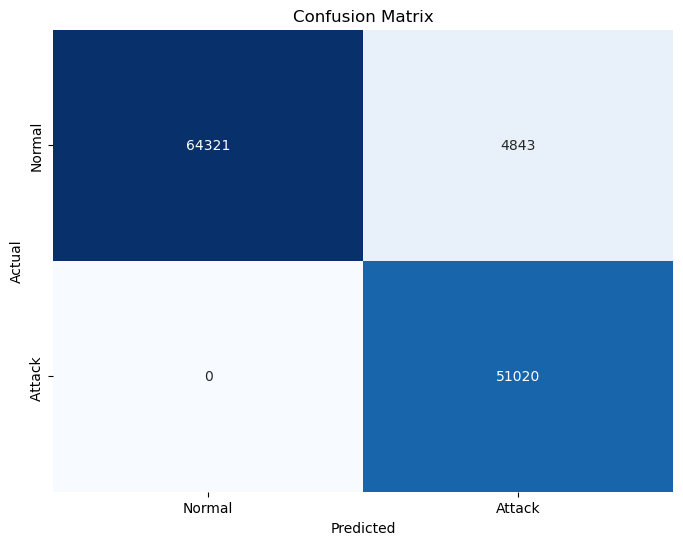

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm= confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack '])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

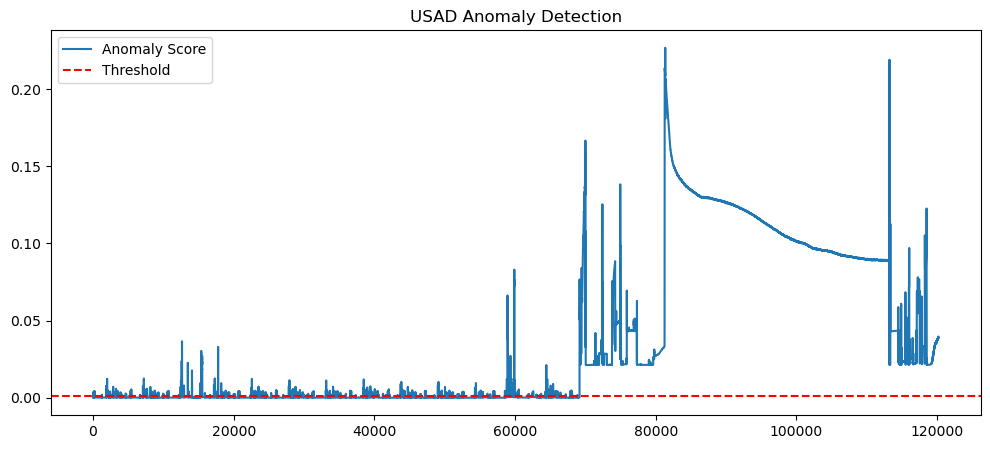

In [20]:
plt.figure(figsize=(12,5))

plt.plot(anomaly_score, label="Anomaly Score")
plt.axhline(best_threshold, color="red", linestyle="--", label="Threshold")

plt.legend()
plt.title("USAD Anomaly Detection")

plt.show()

In [21]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, anomaly_score)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

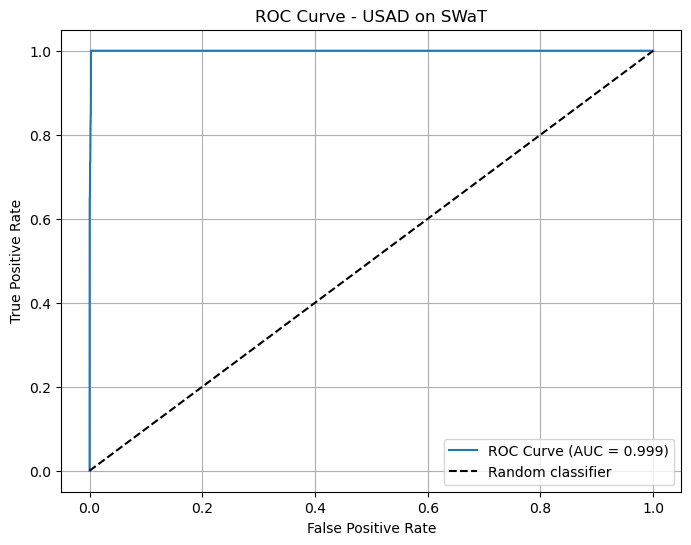

In [22]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.3f})")
plt.plot([0,1],[0,1],'k--',label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - USAD on SWaT")
plt.legend()
plt.grid(True)

plt.show()

# Saving

In [23]:
MODEL_PATH = os.path.join(BASE_PATH, "models")

In [24]:
torch.save(model.state_dict(), os.path.join(MODEL_PATH, "usad_swat_weights.pth"))
torch.save(model, os.path.join(MODEL_PATH, "usad_swat_model_full.pth"))